# Importing Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
# Deep Learning (RNN & LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


# LOADING DATASET

In [2]:
# Load dataset
data = pd.read_csv('/content/max_planck_weather_ts.csv')

# Show first 5 rows
print("First 5 rows of dataset:")
print(data.head())

# Check dataset shape
print("\nDataset Shape (rows, columns):", data.shape)

# Check column names
print("\nColumn Names:")
print(data.columns)

# Check data types
print("\nData Types:")
print(data.dtypes)

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

First 5 rows of dataset:
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       

# Feature Contribution

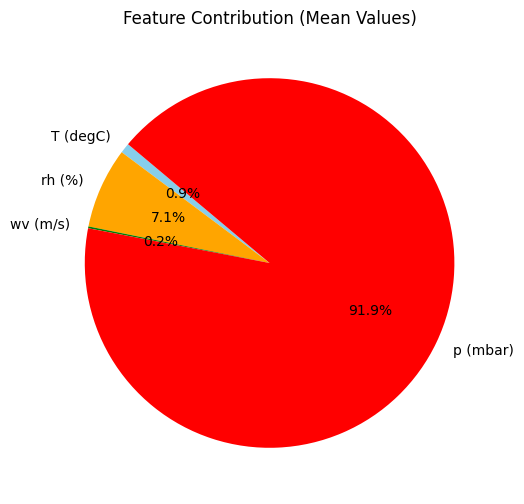

In [3]:
features = data[['T (degC)', 'rh (%)', 'wv (m/s)', 'p (mbar)']]

mean_values = features.mean()

plt.figure(figsize=(6,6))

plt.pie(mean_values,
        labels=mean_values.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['skyblue', 'orange', 'green', 'red'])

plt.title("Feature Contribution (Mean Values)")
plt.show()

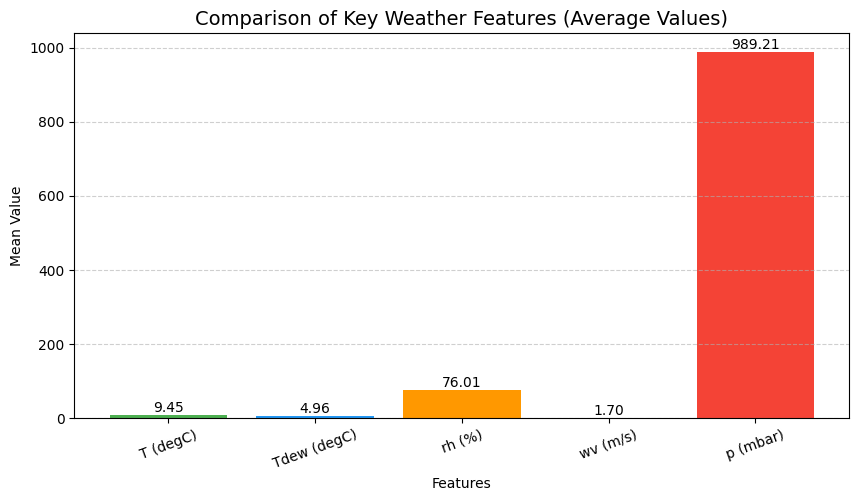

In [4]:
# Select important features
selected_features = data[['T (degC)', 'Tdew (degC)', 'rh (%)', 'wv (m/s)', 'p (mbar)']]

# Calculate mean values
mean_vals = selected_features.mean()

plt.figure(figsize=(10,5))

bars = plt.bar(mean_vals.index, mean_vals.values,
               color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336'])

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval:.2f}', ha='center', va='bottom')

# Design improvements
plt.title("Comparison of Key Weather Features (Average Values)", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

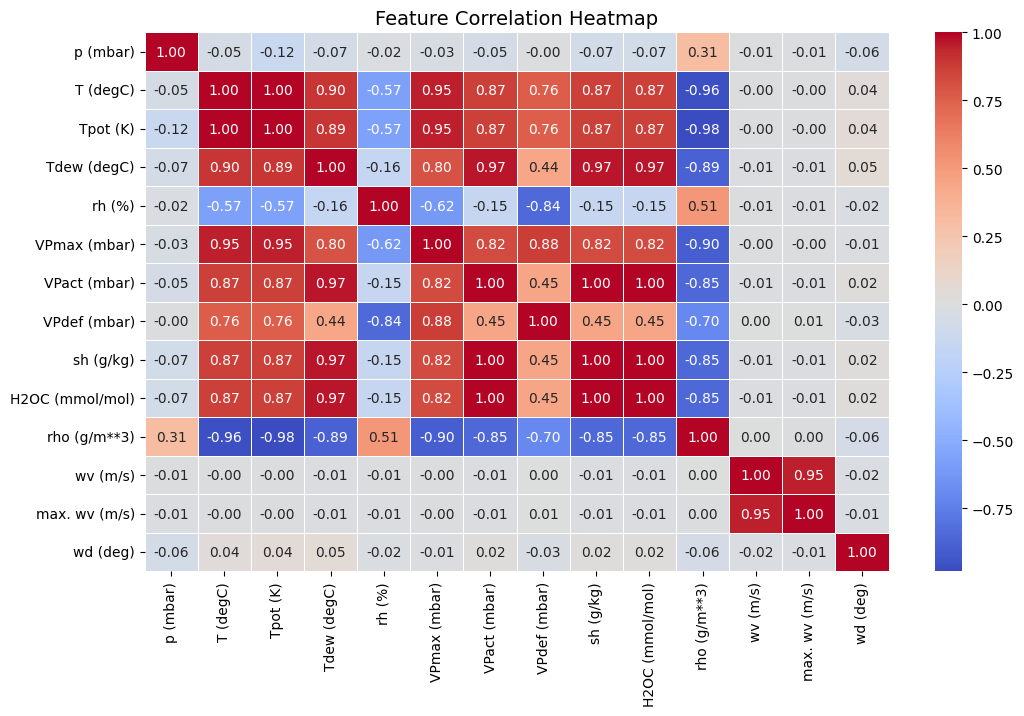

In [5]:

numeric_data = data.drop(columns=['Date Time'])
corr = numeric_data.corr()
plt.figure(figsize=(12,7))

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

# DATA PREPROCESSING

In [6]:
# Convert 'Date Time' column to datetime format
data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')

# Set Date Time as index
data.set_index('Date Time', inplace=True)

# Sort data by time (important for time-series)
data = data.sort_index()

# Select target feature (Temperature)
temp_data = data[['T (degC)']]

# Display processed data
print("Processed Data (first 5 rows):")
print(temp_data.head())

# Check shape
print("\nShape of selected data:", temp_data.shape)

Processed Data (first 5 rows):
                     T (degC)
Date Time                    
2009-01-01 00:10:00     -8.02
2009-01-01 00:20:00     -8.41
2009-01-01 00:30:00     -8.51
2009-01-01 00:40:00     -8.31
2009-01-01 00:50:00     -8.27

Shape of selected data: (420551, 1)


# DATA NORMALIZATION

In [7]:
# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Apply scaling to temperature data
scaled_data = scaler.fit_transform(temp_data)

# Convert back to DataFrame
scaled_data = pd.DataFrame(scaled_data, index=temp_data.index, columns=['T_scaled'])

# Show first 5 rows
print("Scaled Data (first 5 rows):")
print(scaled_data.head())

Scaled Data (first 5 rows):
                     T_scaled
Date Time                    
2009-01-01 00:10:00  0.248632
2009-01-01 00:20:00  0.242163
2009-01-01 00:30:00  0.240504
2009-01-01 00:40:00  0.243822
2009-01-01 00:50:00  0.244485


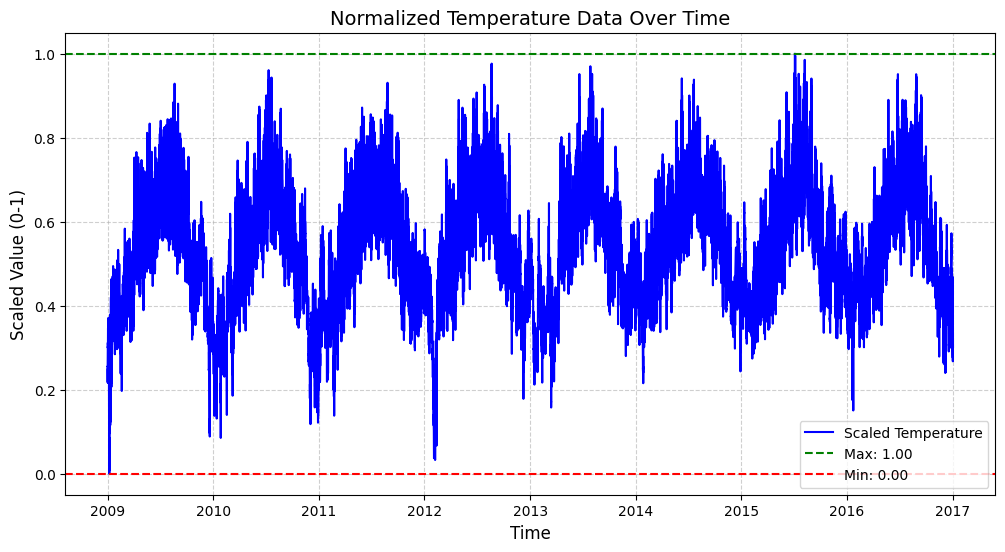

In [8]:
plt.figure(figsize=(12,6))
plt.plot(scaled_data, color='blue', linewidth=1.5, label='Scaled Temperature')

# Highlight max & min points
max_val = scaled_data.max()[0]
min_val = scaled_data.min()[0]

plt.axhline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axhline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.2f}')
plt.title('Normalized Temperature Data Over Time', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Scaled Value (0-1)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()

plt.show()

# CREATE TIME-SERIES SEQUENCES

In [9]:
time_step = 24

# Function to create sequences
def create_dataset(dataset, time_step):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step)])
        y.append(dataset[i + time_step])
    return np.array(X), np.array(y)

# Convert DataFrame to numpy array
dataset = scaled_data.values

# Create sequences
X, y = create_dataset(dataset, time_step)

# Print shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nSample input (X[0]):")
print(X[0])

print("\nSample output (y[0]):")
print(y[0])

Shape of X: (420527, 24, 1)
Shape of y: (420527, 1)

Sample input (X[0]):
[[0.24863161]
 [0.24216288]
 [0.24050423]
 [0.24382153]
 [0.24448499]
 [0.24813402]
 [0.25526621]
 [0.25526621]
 [0.25045613]
 [0.24183115]
 [0.2363576 ]
 [0.23436723]
 [0.23486482]
 [0.23519655]
 [0.23801625]
 [0.23801625]
 [0.23735279]
 [0.23552828]
 [0.23503069]
 [0.23337204]
 [0.23337204]
 [0.23469896]
 [0.23254271]
 [0.23154752]]

Sample output (y[0]):
[0.22856195]


# TRAIN–TEST SPLIT

In [10]:
train_size = int(len(X) * 0.8)

# Split data
X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Print shapes
print("Training Data Shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data Shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training Data Shape:
X_train: (336421, 24, 1)
y_train: (336421, 1)

Testing Data Shape:
X_test: (84106, 24, 1)
y_test: (84106, 1)


# BUILD RNN & LSTM MODELS

# MODEL 1: RNN

In [11]:

model_rnn = Sequential()
model_rnn.add(SimpleRNN(units=10, input_shape=(X_train.shape[1], 1)))

model_rnn.add(Dense(1))

model_rnn.compile(optimizer='adam', loss='mean_squared_error')

print("Reduced RNN Model Summary:")
model_rnn.summary()

Reduced RNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

# MODEL 2: LSTM


In [12]:
model_lstm = Sequential()

model_lstm.add(LSTM(units=50, input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

print("\nLSTM Model Summary:")
model_lstm.summary()


LSTM Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

# TRAINING + FINE-TUNING

#  Train RNN Model

In [13]:
print("Training RNN Model...")

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Training RNN Model...
Epoch 1/3
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - loss: 1.1174e-04 - val_loss: 1.7453e-05
Epoch 2/3
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: 1.6303e-05 - val_loss: 1.2480e-05
Epoch 3/3
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - loss: 1.4106e-05 - val_loss: 1.2372e-05


# Train LSTM Model

In [14]:
print("\nTraining LSTM Model...")

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Training LSTM Model...
Epoch 1/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 130s 12ms/step - loss: 1.3562e-04 - val_loss: 1.6854e-05
Epoch 2/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 127s 12ms/step - loss: 1.4982e-05 - val_loss: 1.2170e-05
Epoch 3/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 129s 12ms/step - loss: 1.3117e-05 - val_loss: 1.5380e-05
Epoch 4/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 129s 12ms/step - loss: 1.2780e-05 - val_loss: 1.5938e-05
Epoch 5/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 141s 12ms/step - loss: 1.2745e-05 - val_loss: 2.1482e-05
Epoch 6/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 129s 12ms/step - loss: 1.2614e-05 - val_loss: 1.1888e-05
Epoch 7/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 152s 13ms/step - loss: 1.2531e-05 - val_loss: 1.8562e-05
Epoch 8/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 129s 12ms/step - loss: 1.2527e-05 - val_loss: 1.4228e-05
Epoch 9/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 129s 12ms/step - loss: 1.2535e-05 - val_loss: 1.1651e-05
Epoch 10/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 140s 12ms/step - loss:

# Fine-Tuning

In [15]:
print("\nTraining Fine-Tuned LSTM Model...")

model_lstm_tuned = Sequential()
model_lstm_tuned.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_lstm_tuned.add(LSTM(50))
model_lstm_tuned.add(Dense(1))

model_lstm_tuned.compile(optimizer='adam', loss='mean_squared_error')

history_lstm_tuned = model_lstm_tuned.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Training Fine-Tuned LSTM Model...
Epoch 1/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 270s 51ms/step - loss: 2.8333e-04 - val_loss: 1.1996e-04
Epoch 2/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 282s 54ms/step - loss: 2.2184e-05 - val_loss: 1.2282e-05
Epoch 3/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 322s 54ms/step - loss: 1.5480e-05 - val_loss: 1.2125e-05
Epoch 4/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 281s 53ms/step - loss: 1.4308e-05 - val_loss: 1.2205e-05
Epoch 5/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 306s 50ms/step - loss: 1.3790e-05 - val_loss: 1.1854e-05
Epoch 6/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 337s 53ms/step - loss: 1.3276e-05 - val_loss: 1.6060e-05
Epoch 7/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 270s 51ms/step - loss: 1.2926e-05 - val_loss: 1.2093e-05
Epoch 8/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 320s 51ms/step - loss: 1.2941e-05 - val_loss: 1.1870e-05
Epoch 9/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 269s 51ms/step - loss: 1.2827e-05 - val_loss: 1.2775e-05
Epoch 10/20
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 266s 51ms/step - loss: 1.2693e-

# PREDICTION + MODEL COMPARISON

In [16]:
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_lstm_tuned = model_lstm_tuned.predict(X_test)

2629/2629 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step


In [17]:
pred_rnn = scaler.inverse_transform(pred_rnn)
pred_lstm = scaler.inverse_transform(pred_lstm)
pred_lstm_tuned = scaler.inverse_transform(pred_lstm_tuned)

y_test_actual = scaler.inverse_transform(y_test)

rmse_rnn = np.sqrt(mean_squared_error(y_test_actual, pred_rnn))
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, pred_lstm))
rmse_lstm_tuned = np.sqrt(mean_squared_error(y_test_actual, pred_lstm_tuned))

print("RNN RMSE:", rmse_rnn)
print("LSTM RMSE:", rmse_lstm)
print("Tuned LSTM RMSE:", rmse_lstm_tuned)

RNN RMSE: 0.21206699216858024
LSTM RMSE: 0.21180611149082104
Tuned LSTM RMSE: 0.20950752012142101


In [18]:
# Calculate metrics
mse_rnn = mean_squared_error(y_test_actual, pred_rnn)
mae_rnn = mean_absolute_error(y_test_actual, pred_rnn)

mse_lstm = mean_squared_error(y_test_actual, pred_lstm)
mae_lstm = mean_absolute_error(y_test_actual, pred_lstm)

mse_lstm_tuned = mean_squared_error(y_test_actual, pred_lstm_tuned)
mae_lstm_tuned = mean_absolute_error(y_test_actual, pred_lstm_tuned)

# Print nicely
print("\nModel Performance Comparison:\n")

print("RNN Model:")
print("MSE:", mse_rnn)
print("RMSE:", rmse_rnn)
print("MAE:", mae_rnn)

print("\nLSTM Model:")
print("MSE:", mse_lstm)
print("RMSE:", rmse_lstm)
print("MAE:", mae_lstm)

print("\nTuned LSTM Model:")
print("MSE:", mse_lstm_tuned)
print("RMSE:", rmse_lstm_tuned)
print("MAE:", mae_lstm_tuned)


Model Performance Comparison:

RNN Model:
MSE: 0.04497240916742867
RMSE: 0.21206699216858024
MAE: 0.1360498132512844

LSTM Model:
MSE: 0.04486182886486211
RMSE: 0.21180611149082104
MAE: 0.14127490487663003

Tuned LSTM Model:
MSE: 0.04389340098742763
RMSE: 0.20950752012142101
MAE: 0.1357249442718402


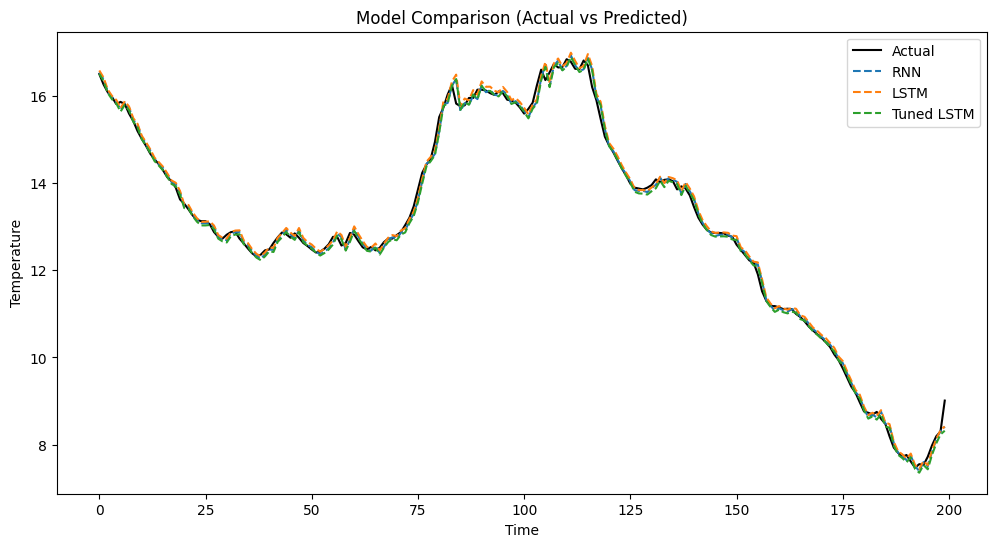

In [19]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual[:200], label='Actual', color='black')
plt.plot(pred_rnn[:200], label='RNN', linestyle='dashed')
plt.plot(pred_lstm[:200], label='LSTM', linestyle='dashed')
plt.plot(pred_lstm_tuned[:200], label='Tuned LSTM', linestyle='dashed')

plt.title("Model Comparison (Actual vs Predicted)")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import r2_score

# Ensure everything is 1D
y_true = scaler.inverse_transform(y_test).reshape(-1)

pred_rnn_flat = scaler.inverse_transform(model_rnn.predict(X_test)).reshape(-1)
pred_lstm_flat = scaler.inverse_transform(model_lstm.predict(X_test)).reshape(-1)
pred_lstm_tuned_flat = scaler.inverse_transform(model_lstm_tuned.predict(X_test)).reshape(-1)

# Calculate R²
r2_rnn = r2_score(y_true, pred_rnn_flat)
r2_lstm = r2_score(y_true, pred_lstm_flat)
r2_lstm_tuned = r2_score(y_true, pred_lstm_tuned_flat)

print("\nCorrect R² Scores:\n")
print(f"RNN: {r2_rnn:.6f}")
print(f"LSTM: {r2_lstm:.6f}")
print(f"Tuned LSTM: {r2_lstm_tuned:.6f}")

2629/2629 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step

Correct R² Scores:

RNN: 0.999313
LSTM: 0.999315
Tuned LSTM: 0.999330


#  MODEL COMPARISON BAR CHART

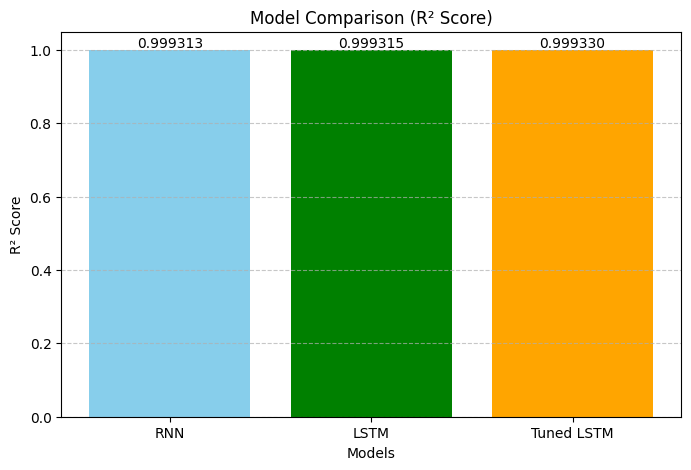

In [21]:
# Data
models = ['RNN', 'LSTM', 'Tuned LSTM']
r2_scores = [r2_rnn, r2_lstm, r2_lstm_tuned]
colors = ['skyblue', 'green', 'orange']

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(models, r2_scores, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval:.6f}', ha='center', va='bottom')

plt.title('Model Comparison (R² Score)')
plt.xlabel('Models')
plt.ylabel('R² Score')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()